# §3.3 What future conditions could indicate the need for upgrades?

This notebook identifies which SoW input factors most reliably signal that a substation will need an upgrade (DSR peak ≥ 3 MW), and the adoption levels at which that need is first triggered. We use PRIM in two steps: first screening which factors are most often important, then re-running on the single most important factor — short-haul (0–99 mi) e-HDT adoption — to locate per-substation trigger points.

**Generates:** Figure 8a & 8b (PRIM factor-importance bars, all substations and truck-stop substations), Figure 8c & 8d (minimum-adoption-trigger ECDFs), and the GeoPackage export behind Figure 9 (minimum-adoption-trigger map, assembled in QGIS), plus the per-substation PRIM example numbers (Newark, Westley) cited in the section text.

## Load modules

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from prim import Prim
from tqdm import tqdm

from laurel.scenario_builders.sense import SenseScenarioReader
from laurel.utils.h3 import H3_CRS, cells_to_region_polygons
from laurel.utils.params import tabularize_params


## Set global variables

In [2]:
## Thresholds and robustness policies
UUR_THRESH = 0.2 # Used-and-useful-robust peak load threshold, only 20% fail to meet
DSR_THRESH = 0.8 # Duty-to-serve-robust peak load threshold, only 20% fail to exceed

PROF_QUANT = 0.95 # Quantile of the load profiles to use in evaluating robustness policies

PRIM_SIG_THRESH = 0.05
PRIM_UPGRADE_THRESH = 3 # MW

UPGRADE_THRESHES = [PRIM_UPGRADE_THRESH, 10]

In [3]:
## Plot colors and styles
sns.set_context("paper", font_scale=1.5)
sns.set_style("whitegrid")

pretty_renamer = {
    "adopt_0_99_miles": "Adopt: 0-99 Miles",
    "adopt_100_249_miles": "Adopt: 100-249 Miles",
    "adopt_250_499_miles": "Adopt: 250-499 Miles",
    "adopt_500plus_miles": "Adopt: 500+ Miles",
    "consump_rate_kwh_per_mi": "Consumption Rate",
    "soc_buffer_low": "Battery Reserve",
    "charge_speed_kw_enroute": "Power: Destination",
    "charge_speed_kw_depot": "Power: Depot",
    "charge_speed_kw_truck_stop": "Power: Truck Stop",
    "manage_charging": "Managed Charging",
}

In [4]:
AREA_CRS = "EPSG:5070" # Conus Albers, in units of meters

## Substations to use as examples
EXAMP_SUBS = {
    9: "Newark - Urban Industrial",
    168: "Laytonville - Rural Highway",
    416: "Westley - Highway Truck Stop",
    422: "Tracy - Warehouses",
}

EXAMP_SUBS_REV = {v: k for k, v in EXAMP_SUBS.items()}

## Load data

In [5]:
%reload_ext kedro.ipython
%reload_kedro --params=data_dir=/scratch/users/passow/laurel/data --env=scenario_builders/sense_manage

[06/11/26 09:28:14] INFO     Using                                                                  ]8;id=113662;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=828785;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#270\270]8;;\
                             '/home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/fr                
                             amework/project/rich_logging.yml' as logging configuration.                           

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=467166;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=726784;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#63\63]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=256790;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=465014;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#65\65]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=590153;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=620153;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:28:17] INFO     Kedro project LAUREL                                                   ]8;id=313032;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=453753;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

...

                    INFO     Registered line magic 'run_viz'                                        ]8;id=320302;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=703390;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

                    INFO     Resolved project path as: /home/users/passow/laurel.                   ]8;id=585171;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=159904;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#180\180]8;;\
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/11/26 09:28:19] INFO     Kedro project LAUREL                                                   ]8;id=297401;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=298381;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#146\146]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=444994;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=769822;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=291176;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=377098;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#153\153]8;;\

In [6]:
reader = SenseScenarioReader(dirs=["sense_manage"])

In [7]:
scen_params = catalog.load("params:scenario_params")
cfgs_parts = catalog.load("scenario_configs")
cfgs = reader.read_partitions(cfgs_parts)
read_keys = {k: v["path"] for k, v in scen_params["variables"].items()}
cfg_df = tabularize_params(
    cfgs=cfgs,
    read_keys=read_keys,
    idx_name=reader.scenario_name,
)

                    INFO     Loading data from params:scenario_params (MemoryDataset)...       ]8;id=225572;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=850414;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

                    INFO     Loading data from scenario_configs (PartitionedDataset)...        ]8;id=645751;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=944925;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

In [8]:
summs_subs_parts = catalog.load("substation.report_by_region_summaries_scenario")
summs_subs = reader.read_partitions(summs_subs_parts, lazy=True)

# Check for incomplete scenarios
incomplete = reader.list_completed_partitions(
    data_partitions=summs_subs_parts,
    config_partitions=cfgs_parts,
    incomplete=True,
    report_type="task",
)
print(f"# of incomplete: {len(incomplete)}")
print(f"incomplete ids: {incomplete}")

[06/11/26 09:28:29] INFO     Loading data from substation.report_by_region_summaries_scenario  ]8;id=598765;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=542886;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\
                             (PartitionedDataset)...                                                               

# of incomplete: 0
incomplete ids: []


In [9]:
hexes = catalog.load("hex_cluster_corresp")
hexes = hexes.dropna(subset=["substation_id"])
hexes["substation_id"] = hexes["substation_id"].astype(int)

[06/11/26 09:28:30] INFO     Loading data from hex_cluster_corresp (FeatherDataset)...         ]8;id=198968;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=948613;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1046\1046]8;;\

## Data preparation

### Load profile summaries

In [10]:
summs_subs_mem = summs_subs.loc[:, ["scenario", f"peak_kw_{PROF_QUANT}", "util_energy_0.5"]]
summs_subs_mem = summs_subs_mem.compute()

In [11]:
summs_subs_clean = summs_subs_mem.reset_index()
summs_subs_clean["substation_id"] = summs_subs_clean["substation_id"].astype(int)
summs_subs_clean = summs_subs_clean.set_index(["scenario", "substation_id"])

summs_subs_clean = summs_subs_clean.rename(columns={f"peak_kw_{PROF_QUANT}": "peak_load_kw", "util_energy_0.5": "util_energy"})
summs_subs_clean["peak_load_mw"] = summs_subs_clean["peak_load_kw"] / 1000
summs_subs_clean = summs_subs_clean.drop(columns=["peak_load_kw"])

### Build geospatial backbone

In [12]:
sub_polys_contin = cells_to_region_polygons(hexes.reset_index(), hex_col="hex_id", region_col="substation_id")
sub_polys_contin = sub_polys_contin.set_index("substation_id")
sub_polys_contin = sub_polys_contin["geometry"]

In [13]:
sub_pts_contin = sub_polys_contin.copy()
sub_pts_contin = sub_pts_contin.to_crs(AREA_CRS)
sub_pts_contin = sub_pts_contin.centroid
sub_pts_contin = sub_pts_contin.to_crs(H3_CRS)

## What future conditions could indicate the need for upgrades?

"For particular substations, what are the boundaries of sets of SoW input factors which frequently co-occur with a peak load of $\geq 3$ MW?"

We answer this with PRIM over the SoW input factors (adoption fractions, charging management, truck-stop charging power, etc.). A substation "requires an upgrade" when its peak load reaches 3 MW in at least 20% of SoWs (the duty-to-serve-robust criterion); peaks use the `PROF_QUANT = 0.95` profile. Unlike §3.1–3.2, this analysis includes SoWs both **with and without** managed charging, so that charging management can itself surface as an indicator.

In [14]:
cfg_prim = cfg_df.copy()
cfg_prim["manage_charging"] = (cfg_prim["manage_charging"] == "MinPowerChargingManager").astype(int)

In [15]:
# Note: Here we include scenarios with AND without managed charging
output_col = "peak_load_mw"
sens_all_subs = summs_subs_clean.loc[:, output_col]

### First, we compare thresholds across substations

**Step 1 — factor importance.** For every substation meeting the upgrade criterion, we run PRIM across all SoW input factors and record which factors appear in its upgrade box; aggregating across substations gives the factor-importance bars in Figure 8a (all substations) and Figure 8b (truck-stop substations). **Step 2 — trigger points (Figures 8c–8d)** re-runs PRIM using only the dominant factor, short-haul (0–99 mi) adoption, to find the minimum adoption level at which each substation first crosses the threshold.

#### Figure 8a: Factor importance — all substations with DSR peak ≥ 3 MW

Generates **Figure 8a**. Bar chart of the share of upgrade-requiring substations (DSR peak ≥ 3 MW) for which each scenario parameter appears in the PRIM-identified upgrade box, across all ~52,000 modeled substations. Identifies which techno-economic factors most reliably indicate upgrade need.

Considering how we could use PRIM to compute boundaries for all substations.

In [16]:
filt_subs = sens_all_subs.groupby("substation_id").quantile(1 - UUR_THRESH)
thresh_name = f"{output_col}_at_{1 - UUR_THRESH}"
filt_subs.name = thresh_name
filt_subs = filt_subs.to_frame()
filt_subs["enough_exceeding"] = filt_subs[thresh_name] > PRIM_UPGRADE_THRESH

In [17]:
prim_subs = filt_subs.loc[filt_subs["enough_exceeding"]].index.values
print(f"Number of PRIM-able substations: {len(prim_subs)}")

Number of PRIM-able substations: 8903


In [18]:
idx = pd.IndexSlice
sub_boxes = {}
for sub in tqdm(prim_subs):
    sub_ser = sens_all_subs.loc[idx[:, sub]]
    sub_df = sub_ser.reset_index().merge(cfg_prim, how="left", on="scenario")
    sub_df = sub_df.drop(columns=["scenario"])
    p = Prim(
        x=sub_df.loc[:, list(scen_params["variables"].keys())],
        y=sub_df.loc[:, output_col],
        threshold=PRIM_UPGRADE_THRESH,
        threshold_type=">",
    )
    box = p.find_box()
    sub_boxes[sub] = box

100%|██████████| 8903/8903 [33:43<00:00,  4.40it/s]  


In [19]:
sub_limits = {k: v.limits for k, v in sub_boxes.items()}
lim_df = pd.concat(sub_limits, axis=0, names=["substation_id", "input_factor"])

[06/11/26 10:04:23] INFO     Saving data to factor_prioritization (MatplotlibDataset)...       ]8;id=649069;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=460196;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

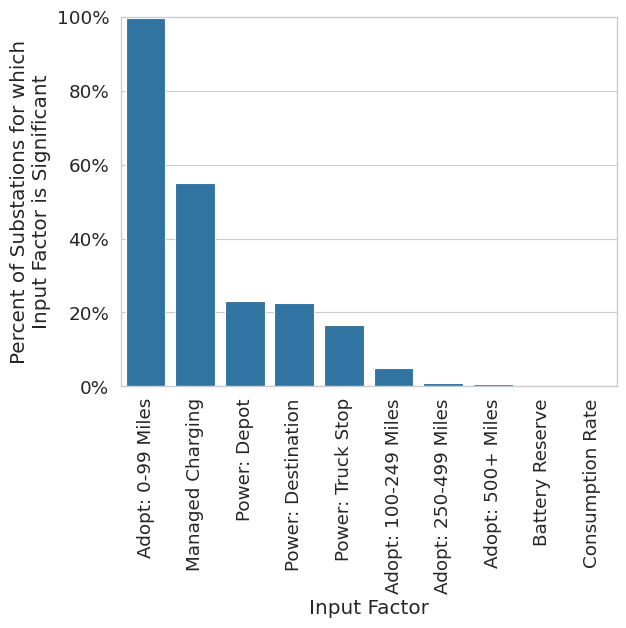

In [20]:
sig_df = lim_df.loc[lim_df["qp values"] < PRIM_SIG_THRESH]
sig_subs = sig_df.index.get_level_values("substation_id").unique().values
plot_df = sig_df.reset_index("input_factor").value_counts("input_factor") / len(sig_subs)
plot_df.index = plot_df.index.map(pretty_renamer)

ax = sns.barplot(data=plot_df)
ax.set_xlabel("Input Factor")
ax.set_ylabel("Percent of Substations for which\nInput Factor is Significant")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(top=1.0)

catalog.save("factor_prioritization", ax.figure)
ax.figure

#### Figure 8b: Factor importance — truck-stop substations

Generates **Figure 8b**. Bar chart of PRIM factor importance restricted to substations that contain at least one truck stop (NAICS 44719007), showing how the indicator ranking shifts when the analysis focuses on freight-critical infrastructure.

In [21]:
tstop_subs = hexes.loc[hexes["loc_group_id"] == "truck_stop", "substation_id"].unique()

[06/11/26 10:04:32] INFO     Saving data to factor_prioritization_truck_stops                  ]8;id=848674;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=621136;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (MatplotlibDataset)...                                                                

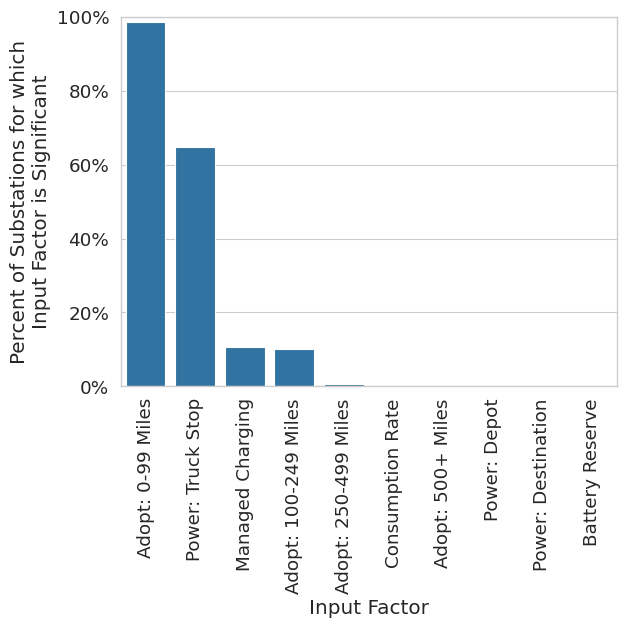

In [22]:
sig_subs = sig_df.index.get_level_values("substation_id").unique().values
sig_tstop_subs = np.intersect1d(tstop_subs, sig_subs)
sig_tstop_df = sig_df.loc[sig_tstop_subs]
plot_df = sig_tstop_df.reset_index("input_factor").value_counts("input_factor") / len(sig_tstop_subs)
plot_df.index = plot_df.index.map(pretty_renamer)

ax = sns.barplot(data=plot_df)
ax.set_xlabel("Input Factor")
ax.set_ylabel("Percent of Substations for which\nInput Factor is Significant")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(top=1.0)

catalog.save("factor_prioritization_truck_stops", ax.figure)
ax.figure

### Figures 8c and 8d: Minimum adoption trigger ECDFs

Generates **Figures 8c** and **8d**. ECDFs of the minimum short-haul (0–99 mi) adoption rate at which each substation first crosses the DSR upgrade threshold (≥ 3 MW peak), for all substations (8c) and truck-stop substations only (8d). Identifies the adoption level below which the majority of substations are unlikely to require upgrades.

In [23]:
chosen_col = "adopt_0_99_miles"

idx = pd.IndexSlice
adopt_boxes = {}
adopt_lims = {}
for sub in tqdm(prim_subs):
    sub_ser = sens_all_subs.loc[idx[:, sub]]
    sub_df = sub_ser.reset_index().merge(cfg_prim, how="left", on="scenario")
    sub_df = sub_df.drop(columns=["scenario"])

    p = Prim(
        x=sub_df.loc[:, chosen_col],
        y=sub_df.loc[:, output_col],
        threshold=PRIM_UPGRADE_THRESH,
        threshold_type=">",
    )
    box = p.find_box()
    adopt_boxes[sub] = box

    # Select the box which meets the coverage criteria
    peel = box.peeling_trajectory
    select_idx = peel.loc[peel["coverage"] > UUR_THRESH, "density"].idxmax()
    box.select(select_idx)
    lims = box.limits
    adopt_lims[sub] = lims.at[chosen_col, "min"]

100%|██████████| 8903/8903 [17:03<00:00,  8.70it/s]


In [24]:
adopt_lims_df = pd.DataFrame.from_dict(adopt_lims, orient="index", columns=["adopt_0_99_miles_min"])
adopt_lims_df.index.name = "substation_id"

[06/11/26 10:21:46] INFO     Saving data to single_factor_minimum (MatplotlibDataset)...       ]8;id=955228;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=915286;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

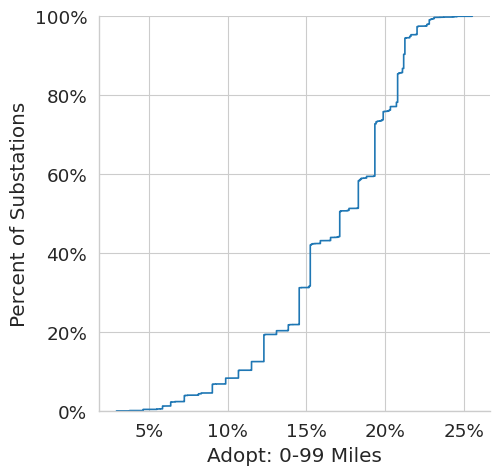

In [25]:
g = sns.displot(data=adopt_lims_df, x="adopt_0_99_miles_min", stat="proportion", kind="ecdf")
g.set_axis_labels(x_var=pretty_renamer["adopt_0_99_miles"], y_var="Percent of Substations")

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))

catalog.save("single_factor_minimum", g.figure)
g.figure

                    INFO     Saving data to single_factor_minimum_truck_stops                  ]8;id=110604;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=751337;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (MatplotlibDataset)...                                                                

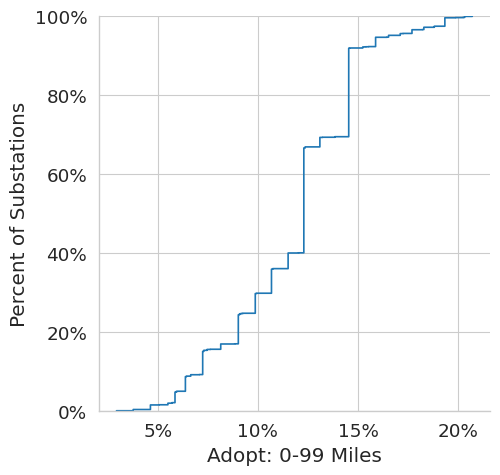

In [26]:
g = sns.displot(data=adopt_lims_df.loc[sig_tstop_subs], x="adopt_0_99_miles_min", stat="proportion", kind="ecdf")
g.set_axis_labels(x_var=pretty_renamer["adopt_0_99_miles"], y_var="Percent of Substations")

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))

catalog.save("single_factor_minimum_truck_stops", g.figure)
g.figure

#### Figure 9: Map of minimum adoption trigger levels

Exports polygon and point GeoDataFrames of per-substation minimum adoption trigger levels, used in QGIS to produce **Figure 9** — a continental U.S. map showing the short-haul e-HDT adoption rate at which each substation first reaches the DSR upgrade threshold.

In [27]:
adopt_lims_polys = adopt_lims_df.copy()
adopt_lims_polys["geometry"] = adopt_lims_polys.index.map(sub_polys_contin)
adopt_lims_polys = gpd.GeoDataFrame(adopt_lims_polys, geometry="geometry", crs=sub_polys_contin.crs)

In [28]:
catalog.save("min_adoption_by_substation", adopt_lims_polys)

                    INFO     Saving data to min_adoption_by_substation (GeoPackageDataset)...  ]8;id=456016;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=44004;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\

In [29]:
adopt_lims_pts = adopt_lims_df.copy()
adopt_lims_pts["geometry"] = adopt_lims_pts.index.map(sub_pts_contin)
adopt_lims_pts = gpd.GeoDataFrame(adopt_lims_pts, geometry="geometry", crs=sub_pts_contin.crs)

In [30]:
catalog.save("min_adoption_by_substation_points", adopt_lims_pts)

[06/11/26 10:21:48] INFO     Saving data to min_adoption_by_substation_points                  ]8;id=268833;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=880710;file:///home/users/passow/laurel/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1006\1006]8;;\
                             (GeoPackageDataset)...                                                                

### Now, we examine individual substations: Numbers used in the section text

#### First, we examine the Newark substation as an example of a substation *without* a truck stop

In [31]:
sens_sub = EXAMP_SUBS_REV["Newark - Urban Industrial"]

In [32]:
idx = pd.IndexSlice
sens_df = sens_all_subs.loc[idx[:, sens_sub]].reset_index()
sens_df = sens_df.merge(cfg_prim, how="left", on="scenario")
sens_df = sens_df.set_index(["scenario"])

In [33]:
(sens_df["peak_load_mw"] > PRIM_UPGRADE_THRESH).sum() / len(sens_df)

np.float64(0.7548828125)

In [34]:
p = Prim(
    x=sens_df.loc[:, list(scen_params["variables"].keys())],
    y=sens_df.loc[:, output_col],
    threshold=PRIM_UPGRADE_THRESH,
    threshold_type=">",
)
box = p.find_box()
box.peeling_trajectory

,coverage,density,mean,res dim,mass
0,1.000000,0.754883,0.754883,0,1.000000
1,1.000000,0.795267,0.795267,1,0.949219
2,0.998706,0.837310,0.837310,1,0.900391
3,0.996119,0.881007,0.881007,1,0.853516
4,0.988357,0.920482,0.920482,1,0.810547
5,0.970246,0.951777,0.951777,1,0.769531
6,0.937904,0.969251,0.969251,1,0.730469
7,0.901682,0.981690,0.981690,1,0.693359
8,0.862872,0.989614,0.989614,1,0.658203
9,0.825356,0.996875,0.996875,2,0.625000


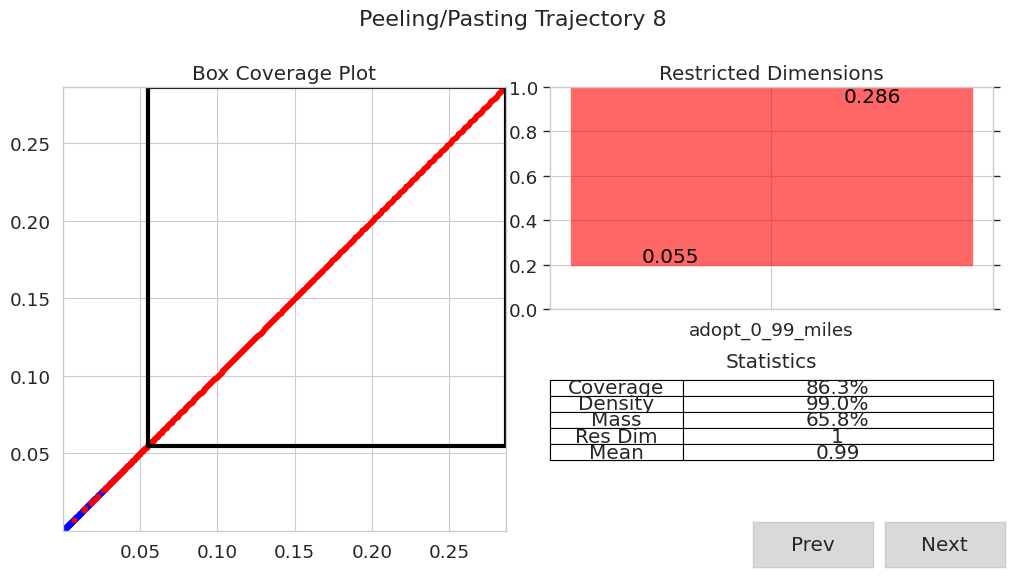

In [35]:
box.select(8)
box.show_details();

In [36]:
box.limits

,min,max,qp values
adopt_0_99_miles,0.054998,0.286281,2.344548e-70


#### Second, we examine the Westley substation as an example of a substation *with* a truck stop

In [37]:
sens_sub = EXAMP_SUBS_REV["Westley - Highway Truck Stop"]

In [38]:
idx = pd.IndexSlice
sens_df = sens_all_subs.loc[idx[:, sens_sub]].reset_index()
sens_df = sens_df.merge(cfg_prim, how="left", on="scenario")
sens_df = sens_df.set_index(["scenario"])

In [39]:
(sens_df["peak_load_mw"] > PRIM_UPGRADE_THRESH).sum() / len(sens_df)

np.float64(0.7275390625)

In [40]:
p = Prim(
    x=sens_df.loc[:, list(scen_params["variables"].keys())],
    y=sens_df.loc[:, output_col],
    threshold=PRIM_UPGRADE_THRESH,
    threshold_type=">",
)
box = p.find_box()
box.peeling_trajectory

,coverage,density,mean,res dim,mass
0,1.000000,0.727539,0.727539,0,1.000000
1,0.994631,0.762346,0.762346,1,0.949219
2,0.986577,0.797180,0.797180,1,0.900391
3,0.974497,0.830664,0.830664,1,0.853516
4,0.958389,0.860241,0.860241,1,0.810547
5,0.934228,0.883249,0.883249,1,0.769531
6,0.908725,0.905080,0.905080,1,0.730469
7,0.876510,0.919718,0.919718,2,0.693359
8,0.848322,0.937685,0.937685,2,0.658203
9,0.817450,0.951562,0.951562,2,0.625000


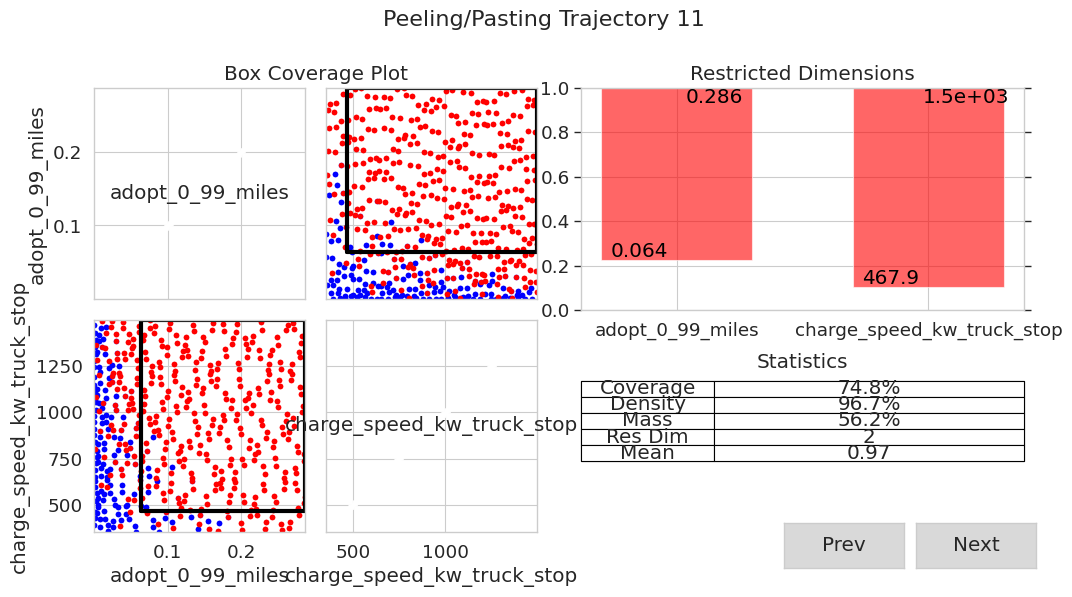

In [41]:
box.select(11)
box.show_details();

In [42]:
box.limits

,min,max,qp values
adopt_0_99_miles,0.063741,0.286281,5.595383e-44
charge_speed_kw_truck_stop,467.919922,1497.753906,1.076150e-03
